In [21]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from utils import get_state_info

# Import your new automated weekly SMAP scraper
from utils import (
    download_smap_growing_season,
    CDL_LEGEND
)


TARGET_YEAR = 2022
EVENT_NAME = "2022 Midwest Flash Drought (Weekly)"
CDL_FILE = f"cdl_{TARGET_YEAR}_19.tif"  # Target Iowa (FIPS 19)
STATE="Nebraska"

In [22]:

# 2. Call the utils function which pulls from the STATE_BBOXES dictionary
fips_code, BBOX = get_state_info(STATE)

# 3. Use these variables in your downstream pipelines!
print(f"\n--- Extracted Variables ---")
print(f"State Name  : {STATE}")
print(f"FIPS Code   : {fips_code}")
print(f"BBOX Values : {BBOX}")


FIPS of Nebraska is 31
BBOX of Nebraska is -680000,1916000,56000,2223000

--- Extracted Variables ---
State Name  : Nebraska
FIPS Code   : 31
BBOX Values : -680000,1916000,56000,2223000


In [23]:

OUT_DIR = "smap_analysis_weekly"
os.makedirs(OUT_DIR, exist_ok=True)

def masked_mean(data, cdl_mask, code):
    v = data[(cdl_mask == code) & ~np.isnan(data)]
    return float(np.mean(v)) if len(v) else np.nan

def masked_std(data, cdl_mask, code):
    v = data[(cdl_mask == code) & ~np.isnan(data)]
    return float(np.std(v)) if len(v) else np.nan


In [24]:
print(f"Executing Batch Fetch for SMAP Data ({TARGET_YEAR})...")

# Your new utils.py function handles the ISO loops and saves the output paths!
downloaded_files = download_smap_growing_season(TARGET_YEAR, out_dir=OUT_DIR,bbox=BBOX)

print(f"\n✓ Ready to process {len(downloaded_files)} consecutive weekly spatial arrays.")


Executing Batch Fetch for SMAP Data (2022)...
  Saved → smap_analysis_weekly/smap_anomaly_2022_w09.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w10.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w11.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w12.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w13.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w14.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w15.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w16.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w17.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w18.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w19.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w20.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w21.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w22.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w23.tif
  Saved → smap_analysis_weekly/smap_anomaly_2022_w24.tif
  Saved → smap_analysis_weekly/smap_anomal

In [25]:
records = []
amaps = []

if not downloaded_files:
    print("Halt: No arrays loaded.")
else:
    # 1. Align the CDL crop boundaries with the SMAP 9km grid
    if os.path.exists(CDL_FILE):
        with rasterio.open(CDL_FILE) as src:
            # Open the first SMAP file to steal its grid dimensions
            with rasterio.open(downloaded_files[0]) as smap_ref:
                target_shape = smap_ref.read(1).shape
            cdl_mask = src.read(1, out_shape=target_shape, resampling=rasterio.enums.Resampling.nearest)
    else:
        print(f"Warning: {CDL_FILE} not found. Synthesizing proxy mask to prevent crash.")
        with rasterio.open(downloaded_files[0]) as smap_ref:
            target_shape = smap_ref.read(1).shape
        np.random.seed(TARGET_YEAR)
        cdl_mask = np.zeros(target_shape, dtype=np.int16)
        r = np.random.random(target_shape)
        cdl_mask[r < 0.35] = 1        
        cdl_mask[(r >= 0.35) & (r < 0.60)] = 5 

    # 2. Sequential Time Series Extraction
    for filepath in downloaded_files:
        # Extract the ISO week out of the generated filename (e.g., 'smap_anomaly_2022_w14.tif')
        filename = os.path.basename(filepath)
        iso_week = int(filename.replace(".tif", "").split("_")[-1][1:])
        
        with rasterio.open(filepath) as src:
            am = src.read(1).astype(np.float32)
            am[am < -10] = np.nan # Clean out CropSmart edge markers
        
        amaps.append(am)
        
        # Determine isolated root-zone anomaly for specific crops
        cm = masked_mean(am, cdl_mask, 1) # Corn
        sm = masked_mean(am, cdl_mask, 5) # Soybeans
        cs = masked_std(am, cdl_mask, 1)
        ss = masked_std(am, cdl_mask, 5)
        
        # Calculate % of Corn Area operating under Severe Deficit (< -0.05)
        corn_severe_cnt = np.sum((am < -0.05) & (cdl_mask == 1) & ~np.isnan(am))
        corn_total_cnt = max(np.sum((cdl_mask == 1) & ~np.isnan(am)), 1)
        sev_pct = (corn_severe_cnt / corn_total_cnt) * 100
        
        records.append({
            "week": iso_week,
            "corn_anom_mean": round(cm, 4) if not np.isnan(cm) else 0,
            "corn_anom_std": round(cs, 4) if not np.isnan(cs) else 0,
            "soy_anom_mean": round(sm, 4) if not np.isnan(sm) else 0,
            "soy_anom_std": round(ss, 4) if not np.isnan(ss) else 0,
            "corn_severe_pct": round(sev_pct, 1)
        })
        
    df = pd.DataFrame(records)
    
    # Save the physical extracted values out to a CSV dashboard
    df.to_csv(os.path.join(OUT_DIR, f"smap_anomaly_stats_{TARGET_YEAR}_{STATE}.csv"), index=False)
    display(df.head()) 


,week,corn_anom_mean,corn_anom_std,soy_anom_mean,soy_anom_std,corn_severe_pct
0,9,-0.1321,0.0680,-0.1304,0.0641,98.4
1,10,-0.1231,0.0677,-0.1218,0.0634,96.2
2,11,-0.1369,0.0744,-0.1349,0.0691,94.5
3,12,-0.1421,0.0798,-0.1382,0.0775,91.9
4,13,-0.1540,0.0783,-0.1504,0.0762,95.6


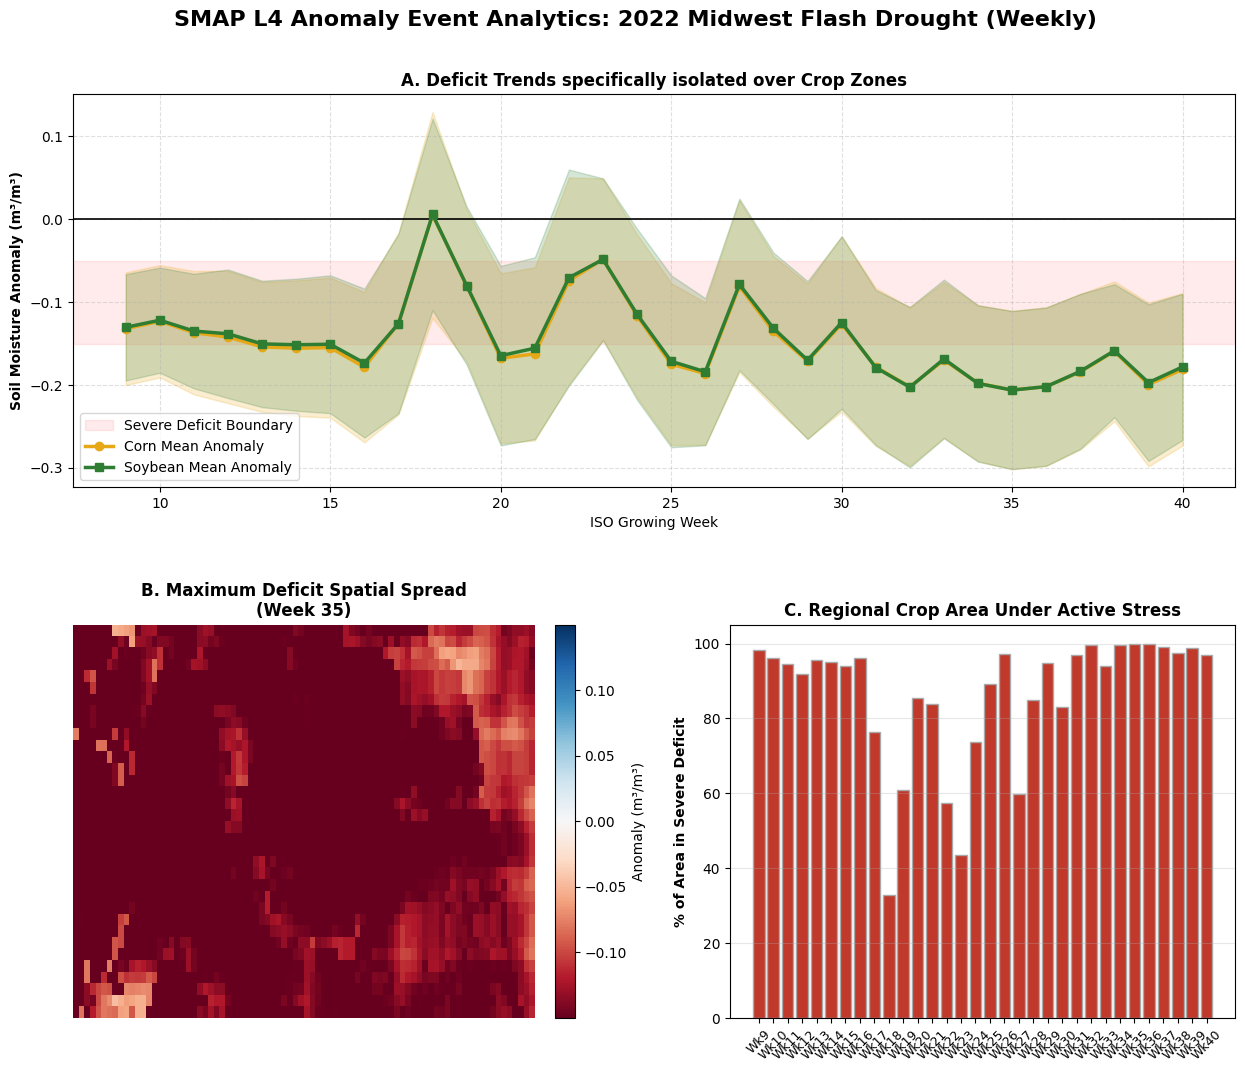

In [26]:
if not df.empty and len(amaps) > 0:
    fig = plt.figure(figsize=(15, 12))
    gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
    
    ax_ts = fig.add_subplot(gs[0, :])
    ax_m  = fig.add_subplot(gs[1, 0])
    ax_sv = fig.add_subplot(gs[1, 1])
    
    fig.suptitle(f"SMAP L4 Anomaly Event Analytics: {EVENT_NAME}", fontsize=16, fontweight="bold", y=0.95)
    
    # ----- PANEL A: Time Series Trend Tracker -----
    weeks_arr = df["week"].values
    ax_ts.axhline(0, color="black", lw=1.2, zorder=2)
    ax_ts.axhspan(-0.05, -0.15, alpha=0.08, color="red", label="Severe Deficit Boundary")
    
    ax_ts.plot(weeks_arr, df["corn_anom_mean"], color="#E6A817", lw=2.5, marker="o", label="Corn Mean Anomaly", zorder=4)
    ax_ts.fill_between(weeks_arr, df["corn_anom_mean"] - df["corn_anom_std"], df["corn_anom_mean"] + df["corn_anom_std"], alpha=0.2, color="#E6A817")
    ax_ts.plot(weeks_arr, df["soy_anom_mean"], color="#2E7D32", lw=2.5, marker="s", label="Soybean Mean Anomaly", zorder=4)
    ax_ts.fill_between(weeks_arr, df["soy_anom_mean"] - df["soy_anom_std"], df["soy_anom_mean"] + df["soy_anom_std"], alpha=0.2, color="#2E7D32")
    
    ax_ts.set_ylabel("Soil Moisture Anomaly (m³/m³)", fontweight="bold")
    ax_ts.set_title("A. Deficit Trends specifically isolated over Crop Zones", fontweight="bold")
    ax_ts.set_xlabel("ISO Growing Week")
    ax_ts.legend(loc="lower left")
    ax_ts.grid(True, alpha=0.4, linestyle="--")
    
    # ----- PANEL B: Trough Spatial Map -----
    trough_idx = df["corn_anom_mean"].idxmin()
    
    anorm = TwoSlopeNorm(vmin=-0.15, vcenter=0.0, vmax=0.15)
    im = ax_m.imshow(amaps[trough_idx], cmap=plt.cm.RdBu, norm=anorm, aspect="auto", interpolation="nearest")
    
    ax_m.set_title(f"B. Maximum Deficit Spatial Spread\n(Week {df.loc[trough_idx, 'week']})", fontweight="bold")
    ax_m.axis("off") # Strip axes for clean map view
    
    cb = plt.colorbar(im, ax=ax_m, fraction=0.046, pad=0.04)
    cb.set_label("Anomaly (m³/m³)")
    
    # ----- PANEL C: Severity Scale Metrics -----
    sev = df["corn_severe_pct"].values
    bcol = ["#C0392B" if s > 30 else "#E67E22" if s > 15 else "#F1C40F" for s in sev]
    
    bars = ax_sv.bar(range(len(sev)), sev, color=bcol, edgecolor="darkgrey", width=0.8)
    ax_sv.set_xticks(range(len(sev)))
    ax_sv.set_xticklabels([f"Wk{w}" for w in weeks_arr], rotation=45, fontsize=9)
    
    ax_sv.set_ylabel("% of Area in Severe Deficit", fontweight="bold")
    ax_sv.set_title("C. Regional Crop Area Under Active Stress", fontweight="bold")
    ax_sv.grid(axis="y", alpha=0.3)
    ax_sv.set_ylim(0, 105)
    
    plt.savefig(os.path.join(OUT_DIR, f"smap_dashboard_{TARGET_YEAR}_{STATE}.png"), dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


In [27]:
import os
import glob

# Set the target folder (e.g., 'smap_analysis_weekly' or 'smap_weekly')
target_folder = "smap_analysis_weekly" 

# Search for all .tif files inside that folder
tif_files = glob.glob(os.path.join(target_folder, "*.tif"))

# Delete them one by one
removed_count = 0
for filepath in tif_files:
    try:
        os.remove(filepath)
        removed_count += 1
    except Exception as e:
        print(f"Failed to delete {filepath}: {e}")

print(f"✓ Deleted {removed_count} .tif files from '{target_folder}'!")


✓ Deleted 32 .tif files from 'smap_analysis_weekly'!
